In [9]:

import pandas as pd
import requests
from datetime import datetime
from time import sleep

# Ruta del archivo original
input_path = "final_silver.csv"
df = pd.read_csv(input_path)

# Asegurar que 'time' está en formato datetime
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# Coordenadas de Mislata, España
latitude = 39.475
longitude = -0.412

# Agrupar fechas únicas del dataset
fechas = sorted(df['time'].dt.strftime('%Y-%m-%d').unique())

# Diccionario para almacenar resultados por fecha
datos_api = {}

# Recolectar datos de Open-Meteo para cada fecha
for fecha in fechas:
    url = (
        "https://archive-api.open-meteo.com/v1/archive?"
        f"latitude={latitude}&longitude={longitude}"
        f"&start_date={fecha}&end_date={fecha}"
        "&hourly=temperature_2m,cloudcover"
        "&timezone=Europe%2FMadrid"
    )
    print(f"Consultando datos para {fecha}...")
    response = requests.get(url)
    if response.status_code == 200:
        datos_api[fecha] = response.json()
    else:
        print(f"⚠ Error al consultar datos de {fecha}")
    sleep(1.2)  # Para evitar bloquear la API

# Reemplazar columnas temperature_mean y cloud_coverage_mean
n_reemplazadas = 0
for idx, row in df.iterrows():
    dt = row['time']
    fecha = dt.strftime('%Y-%m-%d')
    hora = dt.strftime('%H:00')
    try:
        datos_dia = datos_api[fecha]
        idx_hora = datos_dia['hourly']['time'].index(f"{fecha}T{hora}")
        temp = datos_dia['hourly']['temperature_2m'][idx_hora]
        cloud = datos_dia['hourly']['cloudcover'][idx_hora]
        df.at[idx, 'temperature_mean'] = temp
        df.at[idx, 'cloud_coverage_mean'] = cloud
        n_reemplazadas += 1
    except Exception as e:
        print(f"No se pudo reemplazar fila {idx} ({fecha} {hora}): {e}")

# Guardar el nuevo archivo
output_path = "final_silver_sustituido.csv"
df.to_csv(output_path, index=False)
print(f"\nActualización completa. Total reemplazadas: {n_reemplazadas}")
print(f"Archivo guardado en: {output_path}")

'\nimport pandas as pd\nimport requests\nfrom datetime import datetime\nfrom time import sleep\n\n# Ruta del archivo original\ninput_path = "final_silver.csv"\ndf = pd.read_csv(input_path)\n\n# Asegurar que \'time\' está en formato datetime\ndf[\'time\'] = pd.to_datetime(df[\'time\'], errors=\'coerce\')\n\n# Coordenadas de Mislata, España\nlatitude = 39.475\nlongitude = -0.412\n\n# Agrupar fechas únicas del dataset\nfechas = sorted(df[\'time\'].dt.strftime(\'%Y-%m-%d\').unique())\n\n# Diccionario para almacenar resultados por fecha\ndatos_api = {}\n\n# Recolectar datos de Open-Meteo para cada fecha\nfor fecha in fechas:\n    url = (\n        "https://archive-api.open-meteo.com/v1/archive?"\n        f"latitude={latitude}&longitude={longitude}"\n        f"&start_date={fecha}&end_date={fecha}"\n        "&hourly=temperature_2m,cloudcover"\n        "&timezone=Europe%2FMadrid"\n    )\n    print(f"Consultando datos para {fecha}...")\n    response = requests.get(url)\n    if response.status_co

In [10]:
import pandas as pd

#[1:] para no coger los datos nulos de los sensores 2 y 3 y tiempo
df = pd.read_csv('final_silver_sustituido.csv')[2:]

df.isna().sum()


time                                         0
sensor.sensor_temperatura_1_humidity         0
sensor.sensor_temperatura_1_pressure         0
sensor.sensor_temperatura_1_temperature      0
sensor.sensor_temperatura_2_humidity         0
sensor.sensor_temperatura_2_pressure         0
sensor.sensor_temperatura_2_temperature      0
sensor.sensor_temperatura_3_humidity       905
sensor.sensor_temperatura_3_pressure       905
sensor.sensor_temperatura_3_temperature    905
sensor.sensor_temperatura_4_humidity       905
sensor.sensor_temperatura_4_pressure       905
sensor.sensor_temperatura_4_temperature    905
sensor_puerta_1 Puerta                       0
suma_ventanas_arriba                         0
suma_ventanas_abajo                          0
azimuth_mean                                 1
elevation_mean                               1
temperature_mean                             0
cloud_coverage_mean                          0
temperature ℃                                0
dtype: int64

In [11]:
# Print de las filas que tienen valores nulos o vacíos en la columna "azimuth_mean"
df[df["azimuth_mean"].isna() | (df["azimuth_mean"] == '')]
df = df.drop(2077).reset_index(drop=True)
df = df.drop(0).reset_index(drop=True)

In [12]:
df.isna().sum()

time                                         0
sensor.sensor_temperatura_1_humidity         0
sensor.sensor_temperatura_1_pressure         0
sensor.sensor_temperatura_1_temperature      0
sensor.sensor_temperatura_2_humidity         0
sensor.sensor_temperatura_2_pressure         0
sensor.sensor_temperatura_2_temperature      0
sensor.sensor_temperatura_3_humidity       904
sensor.sensor_temperatura_3_pressure       904
sensor.sensor_temperatura_3_temperature    904
sensor.sensor_temperatura_4_humidity       904
sensor.sensor_temperatura_4_pressure       904
sensor.sensor_temperatura_4_temperature    904
sensor_puerta_1 Puerta                       0
suma_ventanas_arriba                         0
suma_ventanas_abajo                          0
azimuth_mean                                 0
elevation_mean                               0
temperature_mean                             0
cloud_coverage_mean                          0
temperature ℃                                0
dtype: int64

In [13]:
from datetime import time

# Asegúrate de que 'time' sea tipo datetime o datetime.time
df['horas'] = pd.to_datetime(df['time']).dt.time

# Filtra entre las 7:00 y las 21:00
df = df[(df['horas'] >= time(7, 0)) & (df['horas'] <= time(21, 0))]
df.drop(columns=['horas'], inplace=True)

df.to_csv('final_silver_v2.csv')
df

,time,sensor.sensor_temperatura_1_humidity,sensor.sensor_temperatura_1_pressure,sensor.sensor_temperatura_1_temperature,sensor.sensor_temperatura_2_humidity,sensor.sensor_temperatura_2_pressure,sensor.sensor_temperatura_2_temperature,sensor.sensor_temperatura_3_humidity,sensor.sensor_temperatura_3_pressure,sensor.sensor_temperatura_3_temperature,...,sensor.sensor_temperatura_4_pressure,sensor.sensor_temperatura_4_temperature,sensor_puerta_1 Puerta,suma_ventanas_arriba,suma_ventanas_abajo,azimuth_mean,elevation_mean,temperature_mean,cloud_coverage_mean,temperature ℃
0,2024-12-10 21:00:00,46.30,1014.60,19.74,46.75,1014.20,19.59,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,285.41,-53.48,12.5,100.0,21.7
10,2024-12-11 07:00:00,51.23,1013.77,19.48,50.87,1014.40,19.14,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,122.93,2.68,7.7,93.0,19.6
11,2024-12-11 08:00:00,56.99,1015.33,21.06,55.78,1014.73,21.09,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,131.90,10.43,7.8,49.0,19.6
12,2024-12-11 09:00:00,58.04,1015.40,21.16,55.98,1015.15,21.58,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,144.64,18.67,7.0,48.0,20.5
13,2024-12-11 10:00:00,52.73,1015.58,20.65,52.90,1015.60,21.06,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,158.21,24.19,7.7,8.0,21.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2491,2025-03-24 17:00:00,46.49,1010.50,20.92,45.89,1010.08,21.47,46.44,1010.25,21.08,...,1010.45,21.35,3600.0,0.0,0.0,265.73,7.96,16.2,52.0,21.2
2492,2025-03-24 18:00:00,47.17,1011.50,21.36,46.15,1010.85,21.97,46.77,1010.90,21.55,...,1011.14,21.59,3600.0,0.0,0.0,273.44,-1.18,15.5,87.0,21.3
2493,2025-03-24 19:00:00,47.73,1012.20,21.40,46.69,1012.03,22.08,47.17,1011.94,21.73,...,1012.20,21.69,2366.0,0.0,0.0,283.89,-13.52,14.7,56.0,21.5
2494,2025-03-24 20:00:00,48.80,1013.20,20.71,47.76,1012.90,21.27,47.96,1012.88,21.10,...,1013.17,20.88,0.0,0.0,0.0,295.64,-25.12,13.5,33.0,21.7


In [14]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Crear columnas con la media entre sensor 1 y sensor 2
df['avg_humidity_1_2'] = df[['sensor.sensor_temperatura_1_humidity', 'sensor.sensor_temperatura_2_humidity']].mean(axis=1)
df['avg_pressure_1_2'] = df[['sensor.sensor_temperatura_1_pressure', 'sensor.sensor_temperatura_2_pressure']].mean(axis=1)
df['avg_temperature_1_2'] = df[['sensor.sensor_temperatura_1_temperature', 'sensor.sensor_temperatura_2_temperature']].mean(axis=1)

# Entrenamos modelos separados para cada variable objetivo si hay datos suficientes
def train_and_predict(feature_col, target_col):
    train_data = df[[feature_col, target_col]].dropna()
    if train_data.empty:
        return None

    X_train = train_data[[feature_col]]
    y_train = train_data[target_col]

    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predecir valores faltantes
    missing_mask = df[target_col].isna() & df[feature_col].notna()
    df.loc[missing_mask, target_col] = model.predict(df.loc[missing_mask, [feature_col]]).round(2)

    return model

# Aplicar modelos
model_humidity = train_and_predict('avg_humidity_1_2', 'sensor.sensor_temperatura_3_humidity')
model_pressure = train_and_predict('avg_pressure_1_2', 'sensor.sensor_temperatura_3_pressure')
model_temperature = train_and_predict('avg_temperature_1_2', 'sensor.sensor_temperatura_3_temperature')

# Verificar cuántos valores se rellenaron
filled_counts = {
    'humidity_filled': df['sensor.sensor_temperatura_3_humidity'].notna().sum(),
    'pressure_filled': df['sensor.sensor_temperatura_3_pressure'].notna().sum(),
    'temperature_filled': df['sensor.sensor_temperatura_3_temperature'].notna().sum()
}

# Mostrar resultados
df_predicted = df[['time', 'sensor.sensor_temperatura_3_humidity',
                   'sensor.sensor_temperatura_3_pressure',
                   'sensor.sensor_temperatura_3_temperature']]





df.to_csv('final_silver_sensores_predichos.csv', index=False)

print("Predicción y guardado completados.")

Predicción y guardado completados.


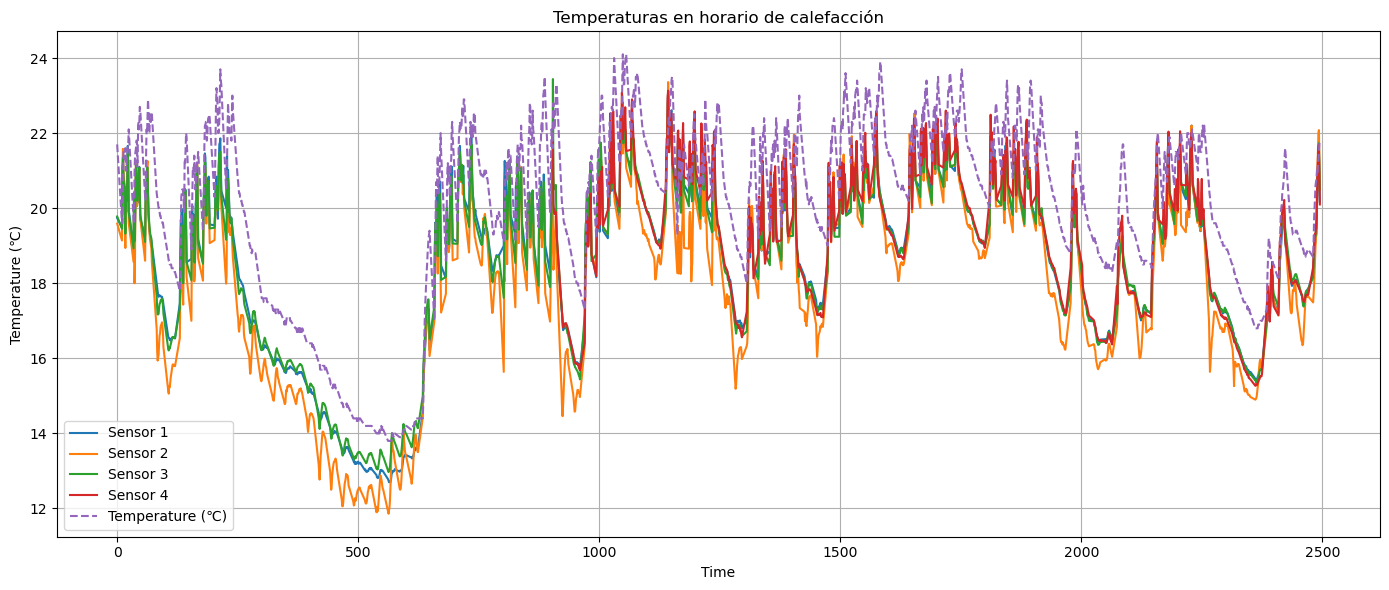

In [15]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df['sensor.sensor_temperatura_1_temperature'], label='Sensor 1')
plt.plot(df['sensor.sensor_temperatura_2_temperature'], label='Sensor 2')
plt.plot(df['sensor.sensor_temperatura_3_temperature'], label='Sensor 3')
plt.plot(df['sensor.sensor_temperatura_4_temperature'], label='Sensor 4')
plt.plot(df['temperature ℃'], label='Temperature (℃)', linestyle='--')

plt.xlabel('Time')
plt.ylabel('Temperature (℃)')
plt.title('Temperaturas en horario de calefacción')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# Crear columnas con la media entre sensor 1 y sensor 2
df['media_humedad'] = df[['sensor.sensor_temperatura_1_humidity', 'sensor.sensor_temperatura_2_humidity', 'sensor.sensor_temperatura_3_humidity']].mean(axis=1)
df['media_presion'] = df[['sensor.sensor_temperatura_1_pressure', 'sensor.sensor_temperatura_2_pressure','sensor.sensor_temperatura_3_pressure']].mean(axis=1)
df['media_temperatura'] = df[['sensor.sensor_temperatura_1_temperature', 'sensor.sensor_temperatura_2_temperature','sensor.sensor_temperatura_3_temperature']].mean(axis=1)

df = df.drop(columns=[
    'sensor.sensor_temperatura_1_humidity',
    'sensor.sensor_temperatura_1_pressure',
    'sensor.sensor_temperatura_1_temperature',
    'sensor.sensor_temperatura_2_humidity',
    'sensor.sensor_temperatura_2_pressure',
    'sensor.sensor_temperatura_2_temperature',
    'sensor.sensor_temperatura_3_humidity',
    'sensor.sensor_temperatura_3_pressure',
    'sensor.sensor_temperatura_3_temperature',
    'sensor.sensor_temperatura_4_humidity',
    'sensor.sensor_temperatura_4_pressure',
    'sensor.sensor_temperatura_4_temperature',
    'avg_humidity_1_2',
    'avg_pressure_1_2',
    'avg_temperature_1_2'
], errors='ignore')

# Formateamos las columnas predichas a 2 decimales
df[['media_humedad', 'media_presion', 'media_temperatura']] = df[['media_humedad', 'media_presion', 'media_temperatura']].round(2)

df.to_csv("final_gold.csv", index=False)

df

,time,sensor_puerta_1 Puerta,suma_ventanas_arriba,suma_ventanas_abajo,azimuth_mean,elevation_mean,temperature_mean,cloud_coverage_mean,temperature ℃,media_humedad,media_presion,media_temperatura
0,2024-12-10 21:00:00,0.0,0.0,0.0,285.41,-53.48,12.5,100.0,21.7,46.42,1014.39,19.70
10,2024-12-11 07:00:00,0.0,0.0,0.0,122.93,2.68,7.7,93.0,19.6,50.96,1014.08,19.36
11,2024-12-11 08:00:00,0.0,0.0,0.0,131.90,10.43,7.8,49.0,19.6,56.30,1015.02,21.08
12,2024-12-11 09:00:00,0.0,0.0,0.0,144.64,18.67,7.0,48.0,20.5,56.93,1015.27,21.36
13,2024-12-11 10:00:00,0.0,0.0,0.0,158.21,24.19,7.7,8.0,21.5,52.73,1015.58,20.86
...,...,...,...,...,...,...,...,...,...,...,...,...
2491,2025-03-24 17:00:00,3600.0,0.0,0.0,265.73,7.96,16.2,52.0,21.2,46.27,1010.28,21.16
2492,2025-03-24 18:00:00,3600.0,0.0,0.0,273.44,-1.18,15.5,87.0,21.3,46.70,1011.08,21.63
2493,2025-03-24 19:00:00,2366.0,0.0,0.0,283.89,-13.52,14.7,56.0,21.5,47.20,1012.06,21.74
2494,2025-03-24 20:00:00,0.0,0.0,0.0,295.64,-25.12,13.5,33.0,21.7,48.17,1012.99,21.03
